In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
path1 = kagglehub.dataset_download("jamescalap/indias-state-wise-air-quality-data-tamil-nadu")
air = pd.read_excel(f"{path1}/India_Air_Quality_Data_For_TamilNadu.xlsx")
print(air.head())

100%|██████████| 521k/521k [00:00<00:00, 93.1MB/s]

Extracting files...


   Stn Code Sampling Date       State City/Town/Village/Area  \
0        38    2010-05-01  Tamil Nadu                Chennai   
1        38    2010-07-01  Tamil Nadu                Chennai   
2        38    2010-12-01  Tamil Nadu                Chennai   
3        38    2010-01-19  Tamil Nadu                Chennai   
4        38    2010-01-21  Tamil Nadu                Chennai   

                     Location of Monitoring Station  \
0  Kathivakkam, Municipal Kalyana Mandapam, Chennai   
1  Kathivakkam, Municipal Kalyana Mandapam, Chennai   
2  Kathivakkam, Municipal Kalyana Mandapam, Chennai   
3  Kathivakkam, Municipal Kalyana Mandapam, Chennai   
4  Kathivakkam, Municipal Kalyana Mandapam, Chennai   

                                    Agency Type of Location    SO2        NO2  \
0  Tamilnadu State Pollution Control Board  Industrial Area   9.60  17.166667   
1  Tamilnadu State Pollution Control Board  Industrial Area  11.15  20.283333   
2  Tamilnadu State Pollution Control Boar

In [3]:
path2 = kagglehub.dataset_download("pyatakov/india-agriculture-crop-production")
crop = pd.read_csv(f"{path2}/India Agriculture Crop Production.csv")
print(crop.head())

100%|██████████| 5.59M/5.59M [00:00<00:00, 54.9MB/s]

Extracting files...


                         State                  District      Crop     Year  \
0  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2001-02   
1  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2002-03   
2  Andaman and Nicobar Islands                  NICOBARS  Arecanut  2003-04   
3  Andaman and Nicobar Islands  NORTH AND MIDDLE ANDAMAN  Arecanut  2001-02   
4  Andaman and Nicobar Islands            SOUTH ANDAMANS  Arecanut  2002-03   

       Season    Area Area Units  Production Production Units     Yield  
0      Kharif  1254.0    Hectare      2061.0           Tonnes  1.643541  
1  Whole Year  1258.0    Hectare      2083.0           Tonnes  1.655803  
2  Whole Year  1261.0    Hectare      1525.0           Tonnes  1.209358  
3      Kharif  3100.0    Hectare      5239.0           Tonnes  1.690000  
4  Whole Year  3105.0    Hectare      5267.0           Tonnes  1.696296  


In [4]:
# Filter air quality for textile districts
air_tn = air[air['City/Town/Village/Area'].isin(['Tiruppur','Erode','Coimbatore'])].copy()
air_tn['Year'] = pd.to_datetime(air_tn['Sampling Date']).dt.year
air_yearly = air_tn.groupby('Year')['RSPM/PM10'].mean().reset_index()

# Filter crop data for Tamil Nadu textile districts
tn = crop[crop['State']=='Tamil Nadu']
crop_tn = tn[tn['District'].isin(['TIRUPPUR','ERODE','COIMBATORE'])]
crop_yearly = crop_tn.groupby('Year')['Yield'].mean().reset_index()
crop_yearly['Year'] = crop_yearly['Year'].str[:4].astype(int)

# Merge on Year
merged = pd.merge(air_yearly, crop_yearly, on='Year')
print(merged)

   Year  RSPM/PM10       Yield
0  2010  78.200487   10.547726
1  2011  85.860215  449.560580
2  2012  68.000000    8.241048
3  2013  55.814947  245.838603
4  2014  49.217241  247.079813
5  2015  46.779736  312.945407


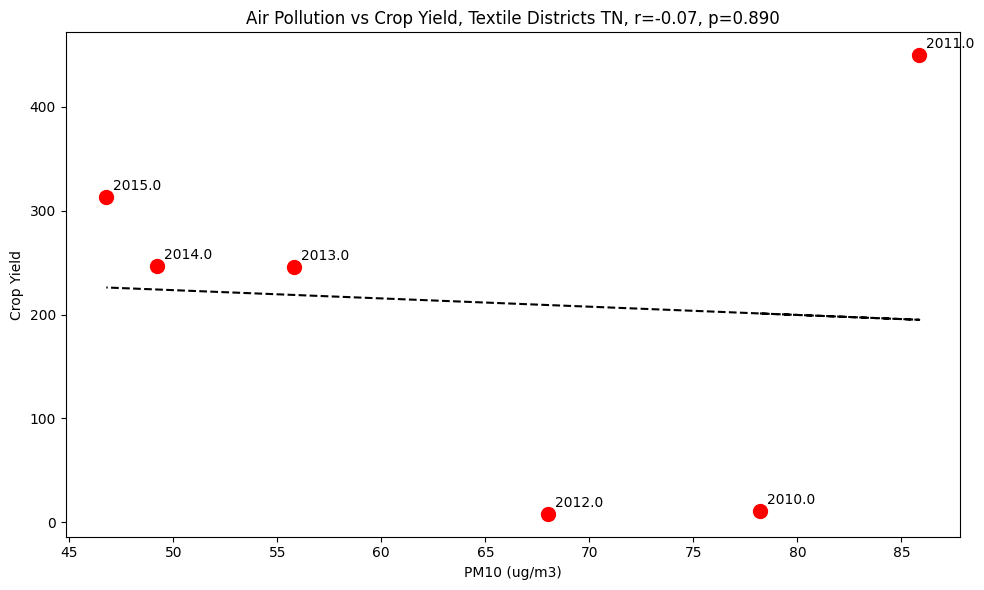

Correlation: -0.07


In [5]:
x, y = merged['RSPM/PM10'], merged['Yield']
slope, intercept, r, p, se = stats.linregress(x, y)

plt.figure(figsize=(10,6))
plt.scatter(x, y, color='red', s=100, zorder=5)
plt.plot(x, slope*x+intercept, color='black', linestyle='--')

for _, row in merged.iterrows():
    plt.annotate(str(row['Year']), (row['RSPM/PM10'], row['Yield']), textcoords="offset points", xytext=(5,5))

plt.title(f'Air Pollution vs Crop Yield, Textile Districts TN, r={r:.2f}, p={p:.3f}')
plt.xlabel('PM10 (ug/m3)')
plt.ylabel('Crop Yield')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()
print(f"Correlation: {r:.2f}")